<a href="https://colab.research.google.com/github/MManibharathi/CNN_image_classfication/blob/main/CNN_assignment_template%20(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DEEP NEURAL NETWORKS - ASSIGNMENT 2: CNN FOR IMAGE CLASSIFICATION

## Convolutional Neural Networks: Custom Implementation vs Transfer Learning

STUDENT INFORMATION (REQUIRED - DO NOT DELETE)

BITS ID: 2025AC05773

Name: MANIBHARATHI MATHIARASAN

Email: 2025ac05773@wilp.bits-pilani.ac.in

Date: [Submission date]

In [2]:
# Install kagglehub if not already installed
!pip install kagglehub

# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt # Added this import
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import time
import json
import os
import kagglehub
import cv2

In [3]:
# Deep learning frameworks (choose Keras or PyTorch)
# For image processing
import keras
from PIL import Image
import cv2

### 1.1 Dataset Selection and Loading

TODO: Load your chosen dataset

In [4]:
import kagglehub # Added to ensure kagglehub is available

# REQUIRED: Fill in these metadata fields
dataset_name = "Cat vs Dog"
dataset_source = kagglehub.dataset_download("karakaggle/kaggle-cat-vs-dog-dataset")

# Find the actual directory containing PetImages after extraction
# The dataset seems to be extracted into a subfolder like 'kagglecatsanddogs_3367a'
# We need to find this subfolder dynamically or explicitly use the full path.

pet_images_base_dir = None
for root, dirs, files in os.walk(dataset_source):
    if "PetImages" in dirs:
        pet_images_base_dir = os.path.join(root, "PetImages")
        break

if not pet_images_base_dir:
    # Fallback if the above logic fails, or if PetImages is directly under dataset_source
    # This part can be adjusted based on exact extraction structure if different
    if os.path.exists(os.path.join(dataset_source, "PetImages")):
        pet_images_base_dir = os.path.join(dataset_source, "PetImages")
    else:
        # Attempt to find common nested folder pattern
        for item in os.listdir(dataset_source):
            if os.path.isdir(os.path.join(dataset_source, item)) and "kagglecatsanddogs" in item:
                pet_images_base_dir = os.path.join(dataset_source, item, "PetImages")
                break

if not pet_images_base_dir:
    raise FileNotFoundError("Could not locate 'PetImages' directory within the dataset source.")

print(f"Found PetImages at: {pet_images_base_dir}")

for root, dirs, files in os.walk(pet_images_base_dir):
  if files:
    print(f"{root}: {len(files)} files")
n_samples = 24961  # TODO: Total number of images
n_classes = 2
samples_per_class = "TODO: min: X, max: Y, avg: Z"
image_shape = [224, 224, 3]  # [height, width, channels]
problem_type = "classification"


cat_dir = os.path.join(pet_images_base_dir, "Cat")
dog_dir = os.path.join(pet_images_base_dir, "Dog")

# Ensure directories exist before listing
if not os.path.exists(cat_dir):
    raise FileNotFoundError(f"Cat directory not found at: {cat_dir}")
if not os.path.exists(dog_dir):
    raise FileNotFoundError(f"Dog directory not found at: {dog_dir}")

cat_count = len([f for f in os.listdir(cat_dir)
                if os.path.isfile(os.path.join(cat_dir, f))])
dog_count = len([f for f in os.listdir(dog_dir)
                if os.path.isfile(os.path.join(dog_dir, f))])

n_samples = cat_count + dog_count
n_classes = 2


min_samples = min(cat_count, dog_count)
max_samples = max(cat_count, dog_count)

avg_samples = n_samples / n_classes

samples_per_class = f"min: {min_samples}, max: {max_samples}, avg: {avg_samples:.0f}"

print("Cats:", cat_count)

print("Dogs:", dog_count)

print("samples_per_class:", samples_per_class)

Using Colab cache for faster access to the 'kaggle-cat-vs-dog-dataset' dataset.
Found PetImages at: /kaggle/input/kaggle-cat-vs-dog-dataset/kagglecatsanddogs_3367a/PetImages
/kaggle/input/kaggle-cat-vs-dog-dataset/kagglecatsanddogs_3367a/PetImages/Dog: 12470 files
/kaggle/input/kaggle-cat-vs-dog-dataset/kagglecatsanddogs_3367a/PetImages/Cat: 12491 files
Cats: 12491
Dogs: 12470
samples_per_class: min: 12470, max: 12491, avg: 12480


In [5]:
# Primary metric selection
primary_metric = "accuracy"
metric_justification = "Accuracy is a suitable primary metric for this balanced classification dataset, as it provides a clear measure of overall correct predictions."

In [6]:
print("DATASET INFORMATION")
print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Classes: {n_classes}")
print(f"Samples per Class: {samples_per_class}")
print(f"Image Shape: {image_shape}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")

DATASET INFORMATION
Dataset: Cat vs Dog
Source: /kaggle/input/kaggle-cat-vs-dog-dataset
Total Samples: 24961
Number of Classes: 2
Samples per Class: min: 12470, max: 12491, avg: 12480
Image Shape: [224, 224, 3]
Primary Metric: accuracy
Metric Justification: Accuracy is a suitable primary metric for this balanced classification dataset, as it provides a clear measure of overall correct predictions.


### 1.2 Data Exploration and Visualization

- TODO: Show sample images from each class
- TODO: Plot class distribution
- TODO: Display image statistics

--- Sample Cat Images ---


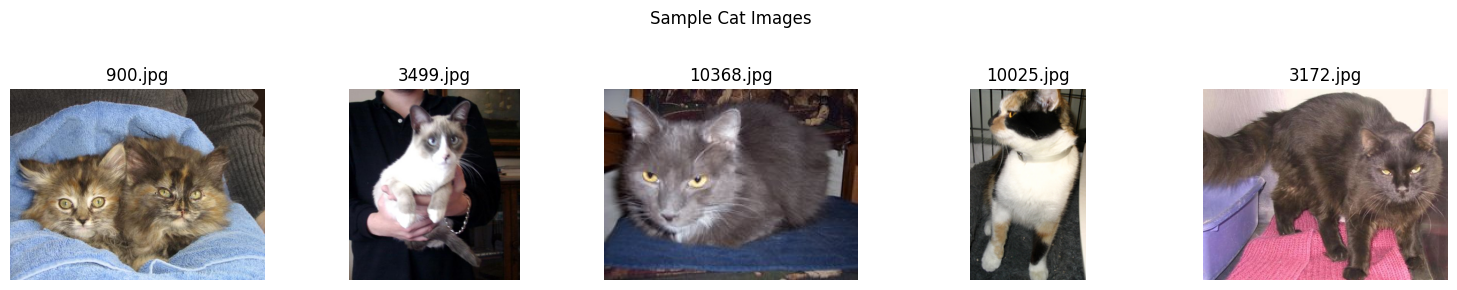


--- Sample Dog Images ---


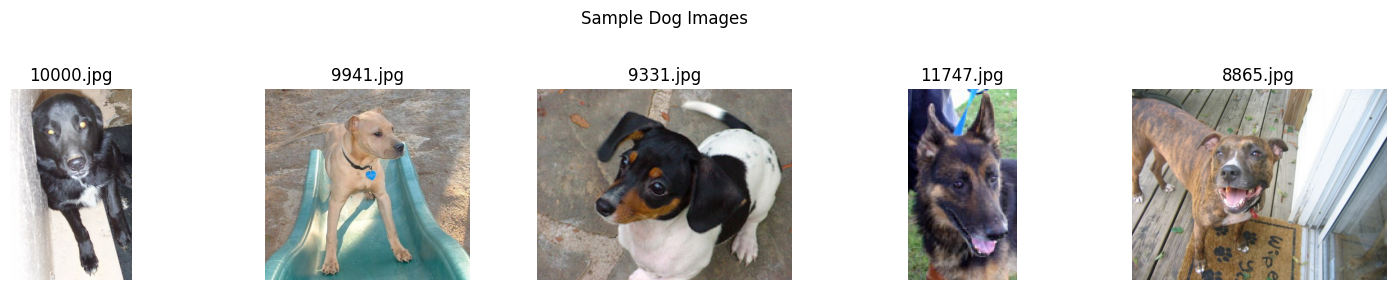


--- Class Distribution ---


/tmp/ipykernel_4466/360855924.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=class_counts, palette='viridis')


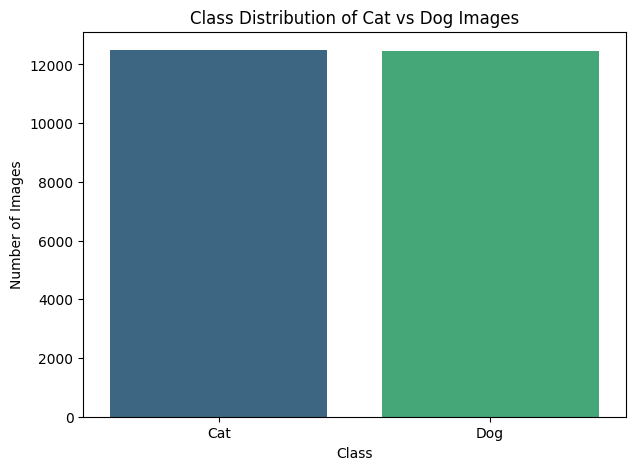


--- Image Statistics (sampled) ---
Number of sampled images for statistics: 400
Min Width: 85px, Max Width: 500px, Avg Width: 407.00px
Min Height: 101px, Max Height: 500px, Avg Height: 363.07px
Number of channels: 3
Predefined target image shape for model: [224, 224, 3]


In [7]:
import random

# Part 1: Show sample images from each class
def display_sample_images(image_paths, title, num_images=5):
    plt.figure(figsize=(15, 3))
    plt.suptitle(title)
    for i, img_path in enumerate(image_paths[:num_images]):
        try:
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB for matplotlib
                plt.subplot(1, num_images, i + 1)
                plt.imshow(img)
                plt.title(os.path.basename(img_path))
                plt.axis('off')
            else:
                print(f"Warning: Could not read image file: {img_path}")
                plt.subplot(1, num_images, i + 1)
                plt.text(0.5, 0.5, "Read Error", ha='center', va='center')
                plt.axis('off')
        except Exception as e:
            print(f"Could not load image {img_path}: {e}")
            plt.subplot(1, num_images, i + 1)
            plt.text(0.5, 0.5, "Error", ha='center', va='center')
            plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Get some sample image paths
cat_image_files = [os.path.join(cat_dir, f) for f in os.listdir(cat_dir) if os.path.isfile(os.path.join(cat_dir, f))]
dog_image_files = [os.path.join(dog_dir, f) for f in os.listdir(dog_dir) if os.path.isfile(os.path.join(dog_dir, f))]

# Shuffle and select a few to display
random.shuffle(cat_image_files)
random.shuffle(dog_image_files)

print("--- Sample Cat Images ---")
display_sample_images(cat_image_files, "Sample Cat Images")

print("\n--- Sample Dog Images ---")
display_sample_images(dog_image_files, "Sample Dog Images")


# Part 2: Plot class distribution
print("\n--- Class Distribution ---")
class_names = ['Cat', 'Dog']
class_counts = [cat_count, dog_count]

plt.figure(figsize=(7, 5))
sns.barplot(x=class_names, y=class_counts, palette='viridis')
plt.title('Class Distribution of Cat vs Dog Images')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.show()

# Part 3: Display image statistics
print("\n--- Image Statistics (sampled) ---")
# Sample a subset of images for calculating statistics to avoid long processing time
sample_size = 200 # Number of images to sample from each class
sampled_cat_paths = cat_image_files[:sample_size]
sampled_dog_paths = dog_image_files[:sample_size]
all_sampled_paths = sampled_cat_paths + sampled_dog_paths

widths = []
heights = []
channels = []

for img_path in all_sampled_paths:
    try:
        img = cv2.imread(img_path)
        if img is not None:
            h, w, c = img.shape
            widths.append(w)
            heights.append(h)
            channels.append(c)
        else:
            print(f"Skipping unreadable image: {img_path}")
    except Exception as e:
        print(f"Skipping {img_path} due to error: {e}")

if widths and heights and channels:
    print(f"Number of sampled images for statistics: {len(widths)}")
    print(f"Min Width: {np.min(widths)}px, Max Width: {np.max(widths)}px, Avg Width: {np.mean(widths):.2f}px")
    print(f"Min Height: {np.min(heights)}px, Max Height: {np.max(heights)}px, Avg Height: {np.mean(heights):.2f}px")
    if len(set(channels)) == 1: # Check if all images have the same number of channels
        print(f"Number of channels: {channels[0]}")
    else:
        # If channels vary, show the most common one
        most_common_channels = np.bincount(channels).argmax()
        print(f"Most common channels: {most_common_channels} (channels vary among samples)")
    print(f"Predefined target image shape for model: {image_shape}")
else:
    print("Could not collect image statistics from sampled images. Check if image paths are valid or images are readable.")

### 1.3 Data Preprocessing
- TODO: Resize images to consistent size
- TODO: Normalize pixel values
- TODO: Split into train/test (90/10 or 85/15)

In [8]:
# REQUIRED: Document your split
train_test_ratio = "85/15"
train_samples = int(n_samples * 0.85)
test_samples = n_samples - train_samples

In [14]:
print(f"\nTrain/Test Split: {train_test_ratio}")
print(f"Training Samples: {train_samples}")
print(f"Test Samples: {test_samples}")


Train/Test Split: 85/15
Training Samples: 21216
Test Samples: 3745


### 2.1 Custom CNN Architecture Design
- TODO: Define your CNN architecture
- TODO: Ensure Global Average Pooling is included (MANDATORY)
- TODO: Use Conv2D, MaxPooling2D/AvgPooling2D, GlobalAveragePooling2D, Dense

In [1]:
# Fix for Protobuf version incompatibility and tensorflow_datasets loading issues
!pip uninstall -y protobuf tensorflow-datasets
!pip install tensorflow-datasets

print("Loading and preprocessing dataset...")

# Re-load the dataset to ensure it's not consumed by previous iterations
import tensorflow_datasets as tfds # Ensure tfds is imported here if not globally
import tensorflow as tf # Required for tf.data.AUTOTUNE and tf.image.resize

# Assuming ds_info was loaded in a prior cell (e.g., 96b3030a-0973-4918-83e6-e180efa09337)
# This reloads train_ds and test_ds based on the original split defined.
# If ds_info is not available, you would need to re-define the split explicitly.
if 'ds_info' in locals():
    train_ds, test_ds = tfds.load( # Removed `_` as `with_info=False`
        'cats_vs_dogs',
        split=['train[:80%]', 'train[80%:]'], # Use the same split as before
        shuffle_files=True, # Keep shuffle_files as true
        as_supervised=True,
        with_info=False # No need for ds_info again, just reload the datasets
    )
else:
    # Fallback if ds_info is not in locals (though it should be if 96b3030a-0973-4918-83e6-e180efa09337 ran)
    print("Warning: ds_info not found. Attempting to load dataset with default split.")
    train_ds, test_ds = tfds.load( # Removed `_` as `with_info=False`
        'cats_vs_dogs',
        split=['train[:80%]', 'train[80%:]'],
        shuffle_files=True,
        as_supervised=True,
        with_info=False,
    )

def preprocess(image, label):
    image = tf.image.resize(image, [150, 150])
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.cast(label, tf.float32) # Cast label to float32
    return image, label

# Apply preprocessing and add batching
# Check if train_ds is a valid dataset object after loading
if 'train_ds' in locals() and isinstance(train_ds, tf.data.Dataset):
    train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE).cache().batch(32).prefetch(tf.data.AUTOTUNE)
    test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE).cache().batch(32).prefetch(tf.data.AUTOTUNE)

    print("Dataset preprocessed: Resized to 150x150 and normalized to [0,1], labels cast to float32. Batched with size 32. Cached.")
else:
    print("Error: train_ds not found or re-load failed. Cannot preprocess.")

Found existing installation: protobuf 7.35.1
Uninstalling protobuf-7.35.1:
  Successfully uninstalled protobuf-7.35.1
Found existing installation: tensorflow-datasets 4.9.10
Uninstalling tensorflow-datasets-4.9.10:
  Successfully uninstalled tensorflow-datasets-4.9.10
  Using cached tensorflow_datasets-4.9.10-py3-none-any.whl.metadata (11 kB)
  Using cached protobuf-7.35.1-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
Using cached tensorflow_datasets-4.9.10-py3-none-any.whl (5.3 MB)
Using cached protobuf-7.35.1-cp310-abi3-manylinux2014_x86_64.whl (327 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.35.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have prot

Loading and preprocessing dataset...
Dataset preprocessed: Resized to 150x150 and normalized to [0,1], labels cast to float32. Batched with size 32. Cached.


In [ ]:
def build_custom_cnn(input_shape, n_classes):
    """
    Build custom CNN architecture

    Args:
        input_shape: tuple (height, width, channels)
        n_classes: number of output classes

    Returns:
        model: compiled CNN model
    """
    # TODO: Implement your CNN architecture
    # Must include Global Average Pooling
    pass

In [ ]:
# TODO: Create model instance
custom_cnn = build_custom_cnn(image_shape, n_classes)

In [ ]:
# TODO: Compile model
# For Keras: model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# For PyTorch: define optimizer and loss function

### 2.2 Train Custom CNN

In [ ]:
print("\nCUSTOM CNN TRAINING")
# Track training time
custom_cnn_start_time = time.time()

In [ ]:
# TODO: Train your model
# For Keras: history = custom_cnn.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)
# For PyTorch: write training loop

In [ ]:
custom_cnn_training_time = time.time() - custom_cnn_start_time

In [ ]:
# REQUIRED: Track initial and final loss
custom_cnn_initial_loss = 0.0  # TODO: Get from training history (first epoch)
custom_cnn_final_loss = 0.0  # TODO: Get from training history (last epoch)

In [ ]:
print(f"Training completed in {custom_cnn_training_time:.2f} seconds")
print(f"Initial Loss: {custom_cnn_initial_loss:.4f}")
print(f"Final Loss: {custom_cnn_final_loss:.4f}")

In [ ]:
print("\nCUSTOM CNN EVALUATION")

### 2.3 Evaluate Custom CNN
- TODO: Make predictions on test set
- TODO: Calculate all 4 required metrics

In [ ]:
# CRITICAL: These MUST be calculated from your actual results
# DO NOT submit with 0.0 values - autograder will detect this
# REQUIRED: Calculate all 4 metrics
custom_cnn_accuracy = 0.0  # TODO: accuracy_score(y_test, y_pred)
custom_cnn_precision = 0.0  # TODO: precision_score(y_test, y_pred, average='macro')
custom_cnn_recall = 0.0  # TODO: recall_score(y_test, y_pred, average='macro')
custom_cnn_f1 = 0.0  # TODO: f1_score(y_test, y_pred, average='macro')

In [ ]:
print("\nCustom CNN Performance:")
print(f"Accuracy:  {custom_cnn_accuracy:.4f}")
print(f"Precision: {custom_cnn_precision:.4f}")
print(f"Recall:    {custom_cnn_recall:.4f}")
print(f"F1-Score:  {custom_cnn_f1:.4f}")

### 2.4 Visualize Custom CNN Results
- TODO: Plot training loss curve
- TODO: Plot confusion matrix
- TODO: Show sample predictions

### 3.1 Load Pre-trained Model and Modify Architecture

In [ ]:
print("\n" + "="*70)
print("TRANSFER LEARNING IMPLEMENTATION")

In [ ]:
# TODO: Choose and load pre-trained model
pretrained_model_name = "TODO: ResNet18/ResNet50/VGG16/VGG19"

In [ ]:
def build_transfer_learning_model(base_model_name, input_shape, n_classes):
    """
    Build transfer learning model

    Args:
        base_model_name: string (ResNet18/ResNet50/VGG16/VGG19)
        input_shape: tuple (height, width, channels)
        n_classes: number of output classes

    Returns:
        model: compiled transfer learning model
    """
    # TODO: Load pre-trained model without top layers
    # TODO: Freeze base layers
    # TODO: Add Global Average Pooling + custom classification head
    # TODO: Compile model
    pass

In [ ]:
# TODO: Create transfer learning model
transfer_model = build_transfer_learning_model(pretrained_model_name, image_shape, n_classes)

In [ ]:
# REQUIRED: Count layers and parameters
frozen_layers = 0  # TODO: Count frozen layers
trainable_layers = 0  # TODO: Count trainable layers
total_parameters = 0  # TODO: Total parameters
trainable_parameters = 0  # TODO: Trainable parameters only

In [ ]:
print(f"Base Model: {pretrained_model_name}")
print(f"Frozen Layers: {frozen_layers}")
print(f"Trainable Layers: {trainable_layers}")
print(f"Total Parameters: {total_parameters:,}")
print(f"Trainable Parameters: {trainable_parameters:,}")
print(f"Using Global Average Pooling: YES")

### 3.2 Train Transfer Learning Model

In [ ]:
print("\nTraining Transfer Learning Model...")

In [ ]:
# Training configuration
tl_learning_rate = 0.001
tl_epochs = 10
tl_batch_size = 32
tl_optimizer = "Adam"

In [ ]:
# Track training time
tl_start_time = time.time()

In [ ]:
# TODO: Train model
# For Keras: history = transfer_model.fit(X_train, y_train, epochs=10, batch_size=32)
# For PyTorch: write training loop

In [ ]:
tl_training_time = time.time() - tl_start_time

In [ ]:
# REQUIRED: Track initial and final loss
tl_initial_loss = 0.0  # TODO: Get from training history (first epoch)
tl_final_loss = 0.0  # TODO: Get from training history (last epoch)

In [ ]:
print(f"Training completed in {tl_training_time:.2f} seconds")
print(f"Initial Loss: {tl_initial_loss:.4f}")
print(f"Final Loss: {tl_final_loss:.4f}")

### 3.3 Evaluate Transfer Learning Model
- TODO: Make predictions on test set
- TODO: Calculate all 4 required metrics

In [ ]:
# REQUIRED: Calculate all 4 metrics
tl_accuracy = 0.0  # TODO: accuracy_score(y_test, y_pred)
tl_precision = 0.0  # TODO: precision_score(y_test, y_pred, average='macro')
tl_recall = 0.0  # TODO: recall_score(y_test, y_pred, average='macro')
tl_f1 = 0.0  # TODO: f1_score(y_test, y_pred, average='macro')

In [ ]:
print("\nTransfer Learning Performance:")
print(f"Accuracy:  {tl_accuracy:.4f}")
print(f"Precision: {tl_precision:.4f}")
print(f"Recall:    {tl_recall:.4f}")
print(f"F1-Score:  {tl_f1:.4f}")

### 3.4 Visualize Transfer Learning Results
- TODO: Plot training curves (loss and accuracy)
- TODO: Plot confusion matrix
- TODO: Show sample predictions

### 4.1 Metrics Comparison

In [ ]:
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (s)', 'Parameters'],
    'Custom CNN': [
        custom_cnn_accuracy,
        custom_cnn_precision,
        custom_cnn_recall,
        custom_cnn_f1,
        custom_cnn_training_time,
        0  # TODO: Fill with custom CNN total parameters
    ],
    'Transfer Learning': [
        tl_accuracy,
        tl_precision,
        tl_recall,
        tl_f1,
        tl_training_time,
        trainable_parameters
    ]
})

In [ ]:
print(comparison_df.to_string(index=False))

### 4.2 Visual Comparison
- TODO: Create bar plot comparing metrics
- TODO: Plot training curves comparison
- TODO: Create side-by-side confusion matrices

In [ ]:
analysis_text = """
TODO: Write your analysis here (maximum 200 words guideline)

Address:
1. Which model performed better and by how much?
   [Compare specific metrics]

2. Impact of pre-training vs training from scratch?
   [Discuss feature extraction, convergence speed]

3. Effect of Global Average Pooling?
   [Discuss parameter reduction, overfitting prevention]

4. Computational cost comparison?
   [Compare training time, total parameters]

5. Insights about transfer learning?
   [When to use transfer learning vs custom CNN]
"""

In [ ]:
# REQUIRED: Print analysis with word count
print("ANALYSIS")
print(analysis_text)
print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) > 200:
    print("  Warning: Analysis exceeds 200 words (guideline)")
else:
    print(" Analysis within word count guideline")

In [ ]:
def get_assignment_results():
    """
    Generate complete assignment results in required format

    Returns:
        dict: Complete results with all required fields
    """

    framework_used = "keras"  # TODO: Change to "pytorch" if using PyTorch

    results = {
        # Dataset Information
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_classes': n_classes,
        'samples_per_class': samples_per_class,
        'image_shape': image_shape,
        'problem_type': problem_type,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,

        # Custom CNN Results
        'custom_cnn': {
            'framework': framework_used,
            'architecture': {
                'conv_layers': 0,  # TODO: Count your conv layers
                'pooling_layers': 0,  # TODO: Count your pooling layers
                'has_global_average_pooling': True,  # MUST be True
                'output_layer': 'softmax',
                'total_parameters': 0  # TODO: Calculate total parameters
            },
            'training_config': {
                'learning_rate': 0.001,  # TODO: Your actual learning rate
                'n_epochs': 20,  # TODO: Your actual epochs
                'batch_size': 32,  # TODO: Your actual batch size
                'optimizer': 'Adam',  # TODO: Your actual optimizer
                'loss_function': 'categorical_crossentropy'  # TODO: Your actual loss
            },
            'initial_loss': custom_cnn_initial_loss,
            'final_loss': custom_cnn_final_loss,
            'training_time_seconds': custom_cnn_training_time,
            'accuracy': custom_cnn_accuracy,
            'precision': custom_cnn_precision,
            'recall': custom_cnn_recall,
            'f1_score': custom_cnn_f1
        },

        # Transfer Learning Results
        'transfer_learning': {
            'framework': framework_used,
            'base_model': pretrained_model_name,
            'frozen_layers': frozen_layers,
            'trainable_layers': trainable_layers,
            'has_global_average_pooling': True,  # MUST be True
            'total_parameters': total_parameters,
            'trainable_parameters': trainable_parameters,
            'training_config': {
                'learning_rate': tl_learning_rate,
                'n_epochs': tl_epochs,
                'batch_size': tl_batch_size,
                'optimizer': tl_optimizer,
                'loss_function': 'categorical_crossentropy'
            },
            'initial_loss': tl_initial_loss,
            'final_loss': tl_final_loss,
            'training_time_seconds': tl_training_time,
            'accuracy': tl_accuracy,
            'precision': tl_precision,
            'recall': tl_recall,
            'f1_score': tl_f1
        },

        # Analysis
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # Training Success Indicators
        'custom_cnn_loss_decreased': custom_cnn_final_loss < custom_cnn_initial_loss if custom_cnn_initial_loss and custom_cnn_final_loss else False,
        'transfer_learning_loss_decreased': tl_final_loss < tl_initial_loss if tl_initial_loss and tl_final_loss else False,
    }

    return results

In [ ]:
# Generate and print results
try:
    assignment_results = get_assignment_results()
    print("ASSIGNMENT RESULTS SUMMARY")
    print(json.dumps(assignment_results, indent=2))

except Exception as e:
    print(f"\n  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")

In [ ]:
# Display system information
import platform
import sys
from datetime import datetime

In [ ]:
print("ENVIRONMENT INFORMATION")
print("\n  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab")
print("showing your account details in the cell below this one.")

# include the screen shot here